# Big Five Personality Test — XGBoost Model Training

**ที่มาของข้อมูล:** Big Five Personality Test (2016–2018) จาก IPIP  
**เป้าหมาย:** ทำนายพฤติกรรมเฉพาะตัว 7 ประการ จากคะแนนบุคลิกภาพ 43 ข้อที่เหลือ

---

### พฤติกรรม 7 ประการที่เป็น Target:
| Column | คำถาม | ด้าน |
|--------|--------|------|
| CSN6 | I often forget to put things back in their proper place. | Conscientiousness |
| AGR9 | I feel others' emotions. | Agreeableness |
| AGR5 | I am not interested in other people's problems. | Agreeableness |
| EXT4 | I keep in the background. | Extraversion |
| EST7 | I change my mood a lot. | Neuroticism |
| OPN3 | I have a vivid imagination. | Openness |
| OPN10 | I am full of ideas. | Openness |

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Loading

In [2]:
df_raw = pd.read_csv('IPIP-FFM-data-8Nov2018/data-final.csv', sep='\t')
print(f'Raw data shape: {df_raw.shape}')
df_raw.head(3)

Raw data shape: (1015341, 110)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833


---
## 2. Data Cleaning & Preparation

In [3]:
# กำหนด 50 คอลัมน์คำถาม
EXT_cols = [f'EXT{i}' for i in range(1, 11)]
EST_cols = [f'EST{i}' for i in range(1, 11)]
AGR_cols = [f'AGR{i}' for i in range(1, 11)]
CSN_cols = [f'CSN{i}' for i in range(1, 11)]
OPN_cols = [f'OPN{i}' for i in range(1, 11)]
all_question_cols = EXT_cols + EST_cols + AGR_cols + CSN_cols + OPN_cols

df = df_raw[all_question_cols].copy()

# Drop missing values
df = df.dropna()

# กรองเฉพาะค่าที่ valid (Likert 1-5 เท่านั้น)
mask_valid = (df >= 1).all(axis=1) & (df <= 5).all(axis=1)
n_removed = (~mask_valid).sum()
df = df[mask_valid].astype(int)

print(f'Records removed (out-of-range): {n_removed}')
print(f'Clean data shape: {df.shape}')

Records removed (out-of-range): 139124
Clean data shape: (874434, 50)


In [4]:
# Reverse Scoring — สำคัญ: ต้องทำก่อนสร้าง features
# XGBoost ใช้ tree-based splits ดังนั้น direction ของ feature มีผลต่อ interpretability
reverse_cols = [
    'EXT2', 'EXT4', 'EXT6', 'EXT8', 'EXT10',
    'EST2', 'EST4',
    'AGR1', 'AGR3', 'AGR5', 'AGR7',
    'CSN2', 'CSN4', 'CSN6', 'CSN8',
    'OPN2', 'OPN4', 'OPN6'
]

df_transformed = df.copy()
df_transformed[reverse_cols] = 6 - df_transformed[reverse_cols]
print(f'Reverse-scored {len(reverse_cols)} columns.')

Reverse-scored 18 columns.


---
## 3. Feature Engineering

XGBoost ทำงานบน raw features ได้ดีอยู่แล้ว แต่เพิ่ม **trait mean scores** เป็น summary features  
ช่วยให้โมเดลจับ "overall personality level" ได้เร็วขึ้นโดยไม่ต้อง learn จาก 10 items เอง

In [5]:
# Trait-level summary features (mean of each Big Five dimension)
df_transformed['EXT_score'] = df_transformed[EXT_cols].mean(axis=1)
df_transformed['EST_score'] = df_transformed[EST_cols].mean(axis=1)
df_transformed['AGR_score'] = df_transformed[AGR_cols].mean(axis=1)
df_transformed['CSN_score'] = df_transformed[CSN_cols].mean(axis=1)
df_transformed['OPN_score'] = df_transformed[OPN_cols].mean(axis=1)

trait_scores = ['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']
print('Trait score statistics:')
df_transformed[trait_scores].describe().round(3)

Trait score statistics:


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
count,874434.000,874434.000,874434.000,874434.000,874434.000
mean,2.959,3.067,3.774,3.366,3.899
std,0.910,0.859,0.729,0.737,0.630
min,1.000,1.000,1.000,1.000,1.000
25%,2.300,2.400,3.300,2.900,3.500
50%,3.000,3.100,3.900,3.400,3.900
75%,3.600,3.700,4.300,3.900,4.400
max,5.000,5.000,5.000,5.000,5.000


In [6]:
# กำหนด Features & Targets
TARGET_COLS = ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']

TARGET_LABELS = {
    'CSN6':  'I often forget to put things back in their proper place. (CSN6)',
    'AGR9':  'I feel others\' emotions. (AGR9)',
    'AGR5':  'I am interested in other people\'s problems. (AGR5)',
    'EXT4':  'I keep in the background. (EXT4)',
    'EST7':  'I change my mood a lot. (EST7)',
    'OPN3':  'I have a vivid imagination. (OPN3)',
    'OPN10': 'I am full of ideas. (OPN10)'
}

# Features = 43 item scores + 5 trait mean scores (ไม่รวม 7 targets)
base_features = [c for c in all_question_cols if c not in TARGET_COLS]
FEATURE_COLS = base_features + trait_scores

X = df_transformed[FEATURE_COLS].copy()
y = df_transformed[TARGET_COLS].copy()

print(f'Features: {len(FEATURE_COLS)} columns (43 items + 5 trait scores)')
print(f'Targets : {len(TARGET_COLS)} columns')
print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')

Features: 48 columns (43 items + 5 trait scores)
Targets : 7 columns
X shape : (874434, 48)
y shape : (874434, 7)


---
## 4. EDA — เฉพาะสิ่งที่ให้ insight สำหรับ XGBoost

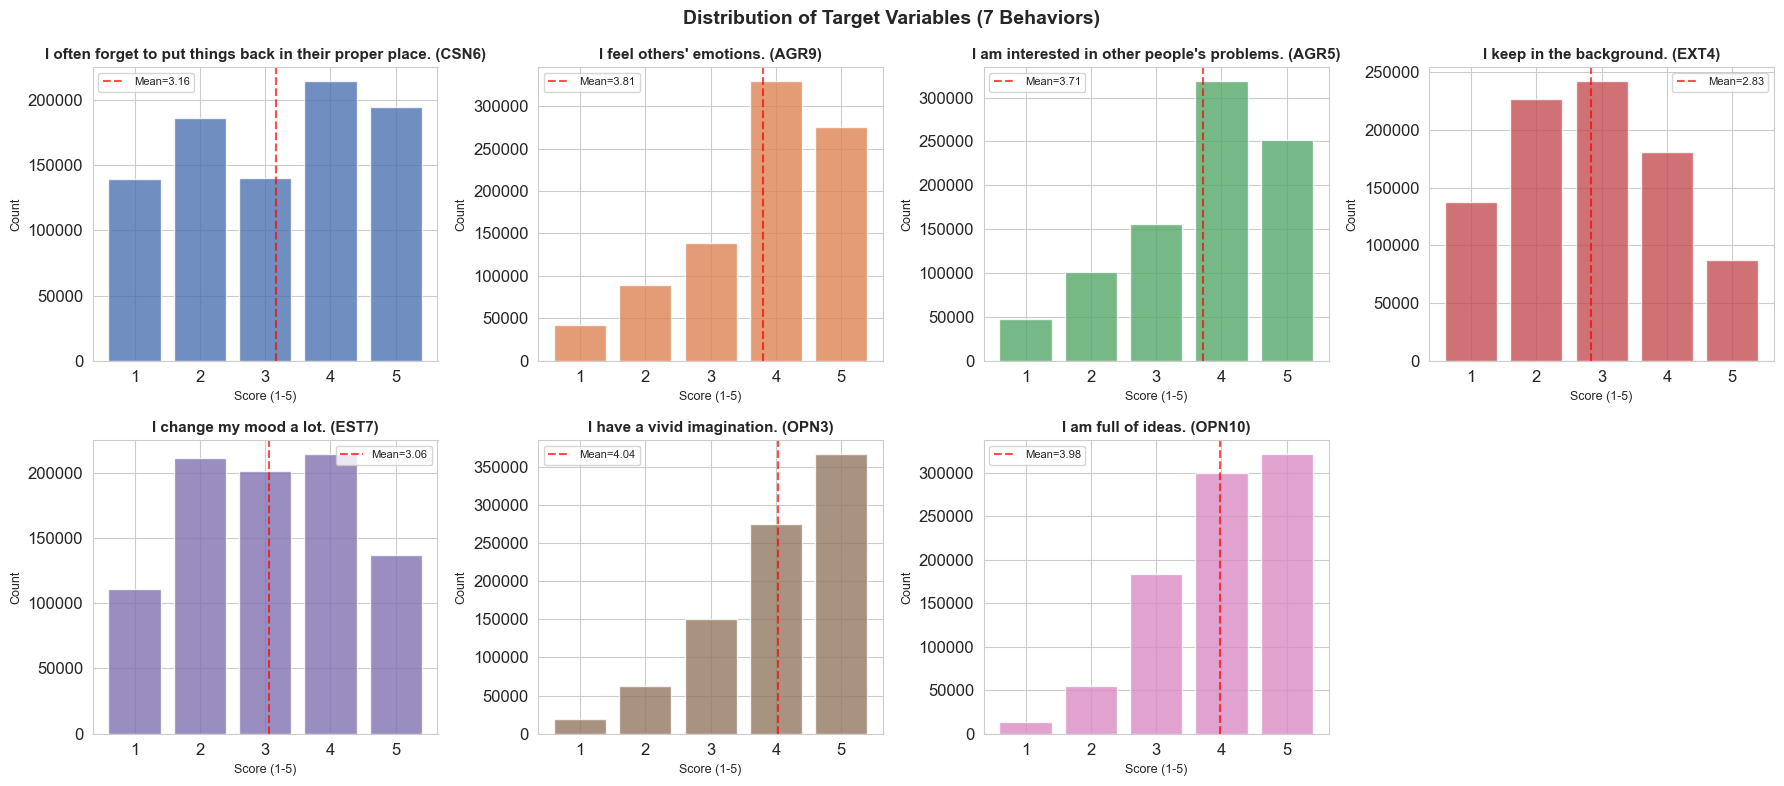

In [7]:
# 4.1 การกระจายของ Target Variables
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

for i, col in enumerate(TARGET_COLS):
    ax = axes[i]
    value_counts = y[col].value_counts().sort_index()
    ax.bar(value_counts.index, value_counts.values, color=colors[i], alpha=0.8, edgecolor='white')
    ax.set_title(TARGET_LABELS[col], fontsize=11, fontweight='bold')
    ax.set_xlabel('Score (1-5)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks([1, 2, 3, 4, 5])
    mean_val = y[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean={mean_val:.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribution of Target Variables (7 Behaviors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

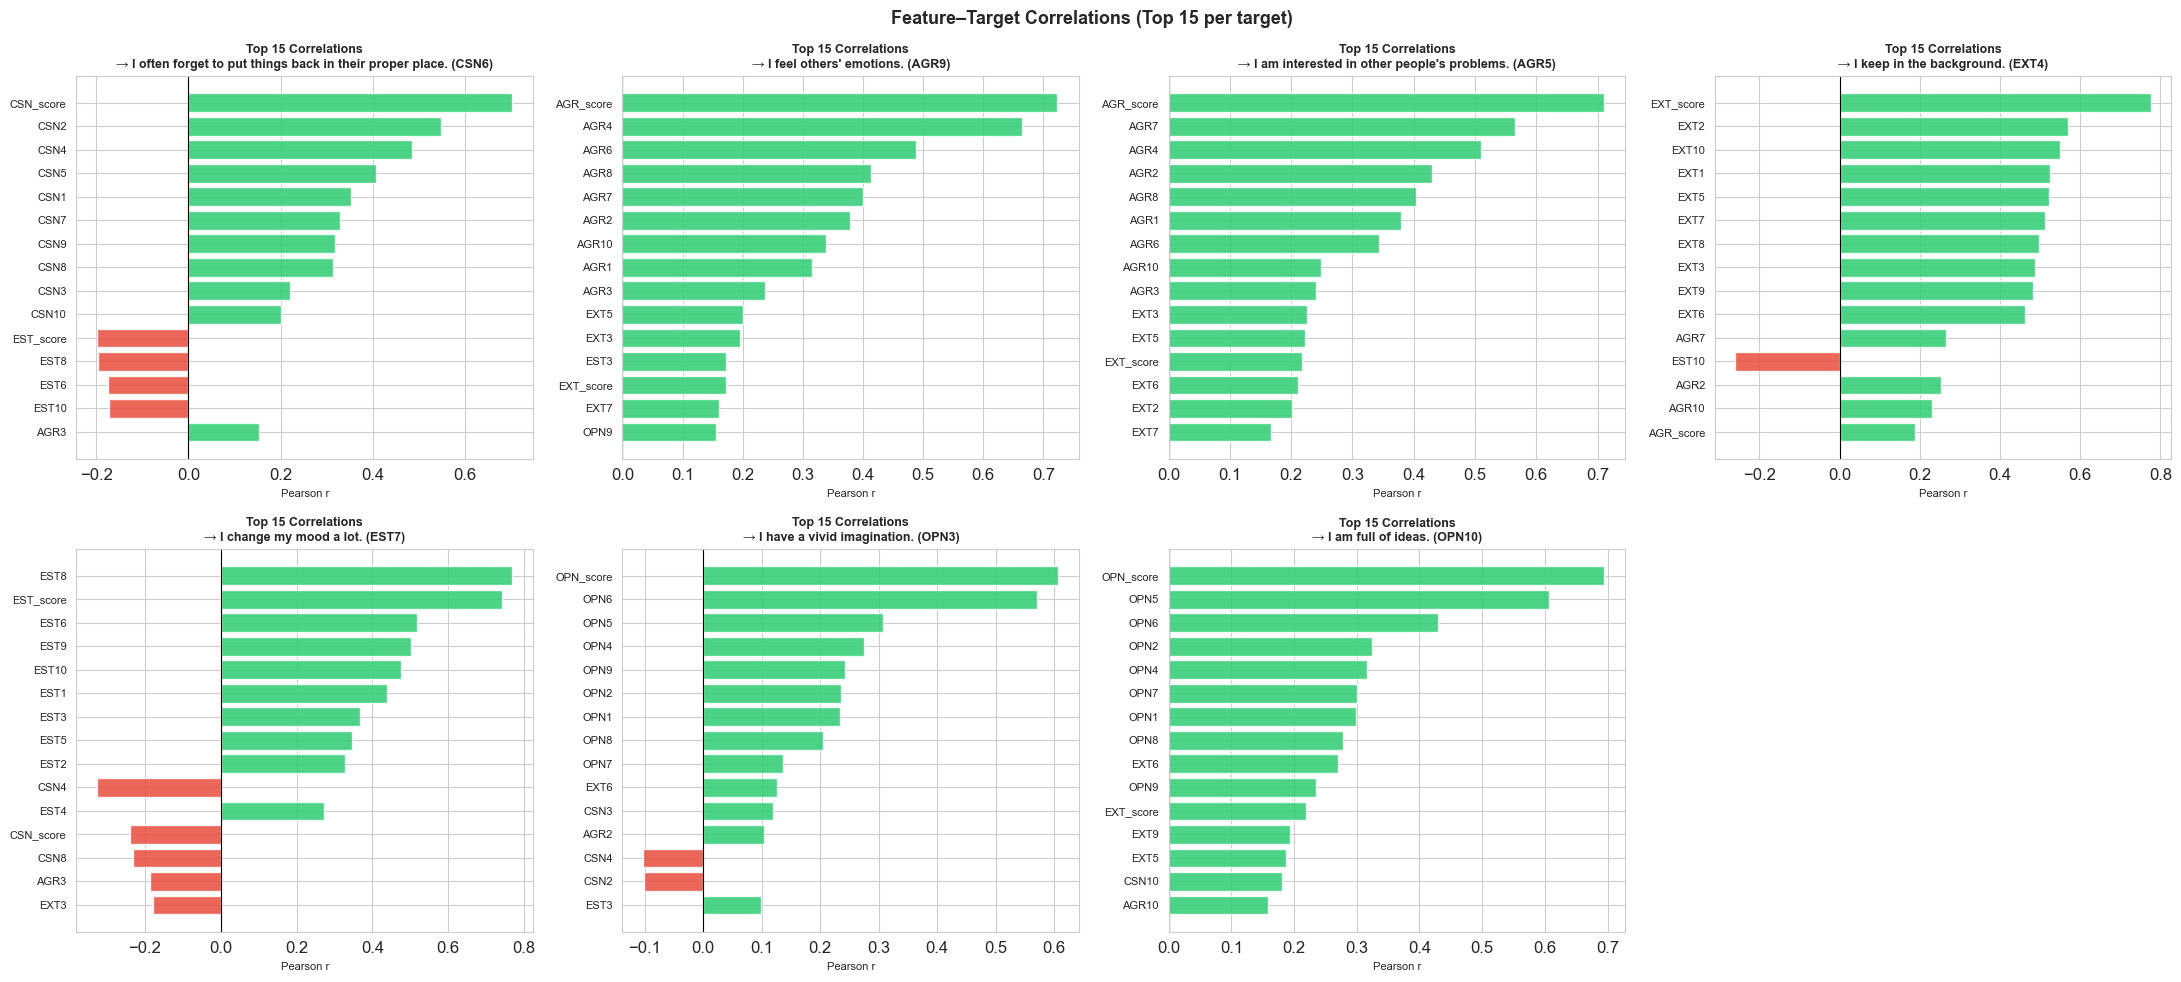

In [8]:
# 4.2 Feature-Target Correlation — ยืนยันว่า signal มีอยู่จริง
# สำคัญ: ถ้า correlation ต่ำมากทุก feature → XGBoost ก็ไม่สามารถ learn ได้
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    corr_vals = X.corrwith(y[target]).sort_values(key=abs, ascending=False).head(15)
    ax = axes[i]
    bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_vals.values]
    ax.barh(corr_vals.index[::-1], corr_vals.values[::-1], color=bar_colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top 15 Correlations\n→ {TARGET_LABELS[target]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Pearson r', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Feature–Target Correlations (Top 15 per target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Model Training — XGBoost

**หมายเหตุ:** XGBoost ไม่ต้องการ `StandardScaler` เพราะ tree-based model ใช้ threshold ตัดสิน ไม่ใช่ distance

เพิ่ม `early_stopping_rounds` เพื่อ:
- หยุดเทรนเมื่อ validation MAE ไม่ดีขึ้น → ป้องกัน overfit
- ลดเวลาเทรนโดยอัตโนมัติ

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: X={X_train.shape}, y={y_train.shape}')
print(f'Test  set: X={X_test.shape},  y={y_test.shape}')

Train set: X=(699547, 48), y=(699547, 7)
Test  set: X=(174887, 48),  y=(174887, 7)


In [10]:
XGB_PARAMS = dict(
    n_estimators=500,          # ตั้งสูงไว้ early stopping จะหยุดเองเมื่อ converge
    max_depth=5,               # ไม่ลึกเกินไป ป้องกัน overfit
    learning_rate=0.05,
    subsample=0.8,             # random sample rows → ลด variance
    colsample_bytree=0.8,      # random sample features per tree
    min_child_weight=3,        # ต้องมีข้อมูลอย่างน้อย 3 samples ใน leaf
    gamma=0.1,                 # minimum loss reduction to split
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=1.0,            # L2 regularization
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=30,  # หยุดถ้า MAE ไม่ดีขึ้น 30 rounds
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

models = {}
results = {}

for target in TARGET_COLS:
    print(f'Training XGBoost for: {TARGET_LABELS[target]} ...', end=' ')

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_test, y_test[target])],
        verbose=False
    )

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    mae_train = mean_absolute_error(y_train[target], y_pred_train)
    mae_test  = mean_absolute_error(y_test[target],  y_pred_test)

    models[target] = model
    results[target] = {
        'MAE_train':   mae_train,
        'MAE_test':    mae_test,
        'best_iter':   model.best_iteration,
        'y_pred_test': y_pred_test
    }
    print(f'best_iter={model.best_iteration:>4}  |  Train MAE={mae_train:.4f}  |  Test MAE={mae_test:.4f}')

print('\nAll models trained successfully.')

Training XGBoost for: I often forget to put things back in their proper place. (CSN6) ... best_iter= 499  |  Train MAE=0.4110  |  Test MAE=0.4165
Training XGBoost for: I feel others' emotions. (AGR9) ... best_iter= 499  |  Train MAE=0.4276  |  Test MAE=0.4299
Training XGBoost for: I am interested in other people's problems. (AGR5) ... best_iter= 499  |  Train MAE=0.4372  |  Test MAE=0.4392
Training XGBoost for: I keep in the background. (EXT4) ... best_iter= 499  |  Train MAE=0.4149  |  Test MAE=0.4163
Training XGBoost for: I change my mood a lot. (EST7) ... best_iter= 499  |  Train MAE=0.4041  |  Test MAE=0.4066
Training XGBoost for: I have a vivid imagination. (OPN3) ... best_iter= 499  |  Train MAE=0.3781  |  Test MAE=0.3809
Training XGBoost for: I am full of ideas. (OPN10) ... best_iter= 499  |  Train MAE=0.3650  |  Test MAE=0.3665

All models trained successfully.


---
## 6. Model Evaluation

In [11]:
# Summary Table
eval_df = pd.DataFrame([
    {
        'Target':      col,
        'พฤติกรรม':   TARGET_LABELS[col],
        'Best Iter':   results[col]['best_iter'],
        'MAE (Train)': round(results[col]['MAE_train'], 4),
        'MAE (Test)':  round(results[col]['MAE_test'],  4),
        'Overfit?':    '⚠️' if results[col]['MAE_test'] - results[col]['MAE_train'] > 0.15 else '✅'
    }
    for col in TARGET_COLS
])

print(eval_df.to_string(index=False))
print(f"\nAverage Test MAE: {eval_df['MAE (Test)'].mean():.4f}")

Target                                                        พฤติกรรม  Best Iter  MAE (Train)  MAE (Test) Overfit?
  CSN6 I often forget to put things back in their proper place. (CSN6)        499       0.4110      0.4165        ✅
  AGR9                                 I feel others' emotions. (AGR9)        499       0.4276      0.4299        ✅
  AGR5              I am interested in other people's problems. (AGR5)        499       0.4372      0.4392        ✅
  EXT4                                I keep in the background. (EXT4)        499       0.4149      0.4163        ✅
  EST7                                  I change my mood a lot. (EST7)        499       0.4041      0.4066        ✅
  OPN3                              I have a vivid imagination. (OPN3)        499       0.3781      0.3809        ✅
 OPN10                                     I am full of ideas. (OPN10)        499       0.3650      0.3665        ✅

Average Test MAE: 0.4080


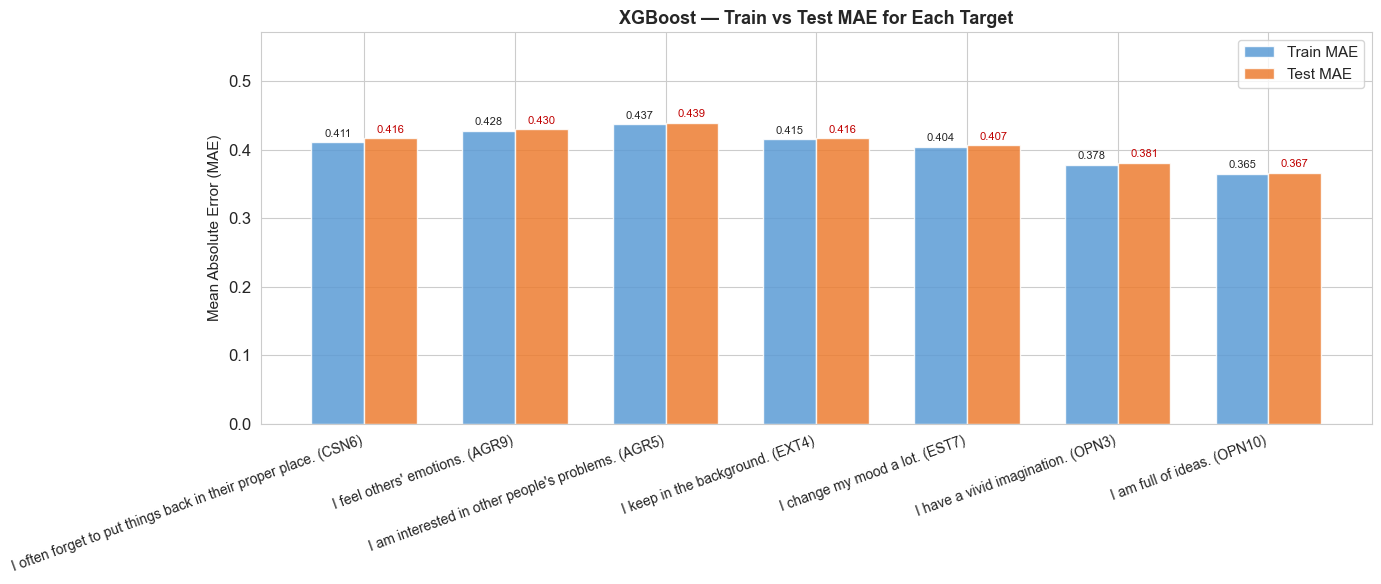

In [12]:
# MAE Comparison Chart
x_labels = [TARGET_LABELS[c] for c in TARGET_COLS]
mae_train_vals = [results[c]['MAE_train'] for c in TARGET_COLS]
mae_test_vals  = [results[c]['MAE_test']  for c in TARGET_COLS]

x = np.arange(len(TARGET_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_train = ax.bar(x - width/2, mae_train_vals, width, label='Train MAE', color='#5B9BD5', alpha=0.85)
bars_test  = ax.bar(x + width/2, mae_test_vals,  width, label='Test MAE',  color='#ED7D31', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=11)
ax.set_title('XGBoost — Train vs Test MAE for Each Target', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(mae_test_vals) * 1.3)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#C00000')

plt.tight_layout()
plt.show()

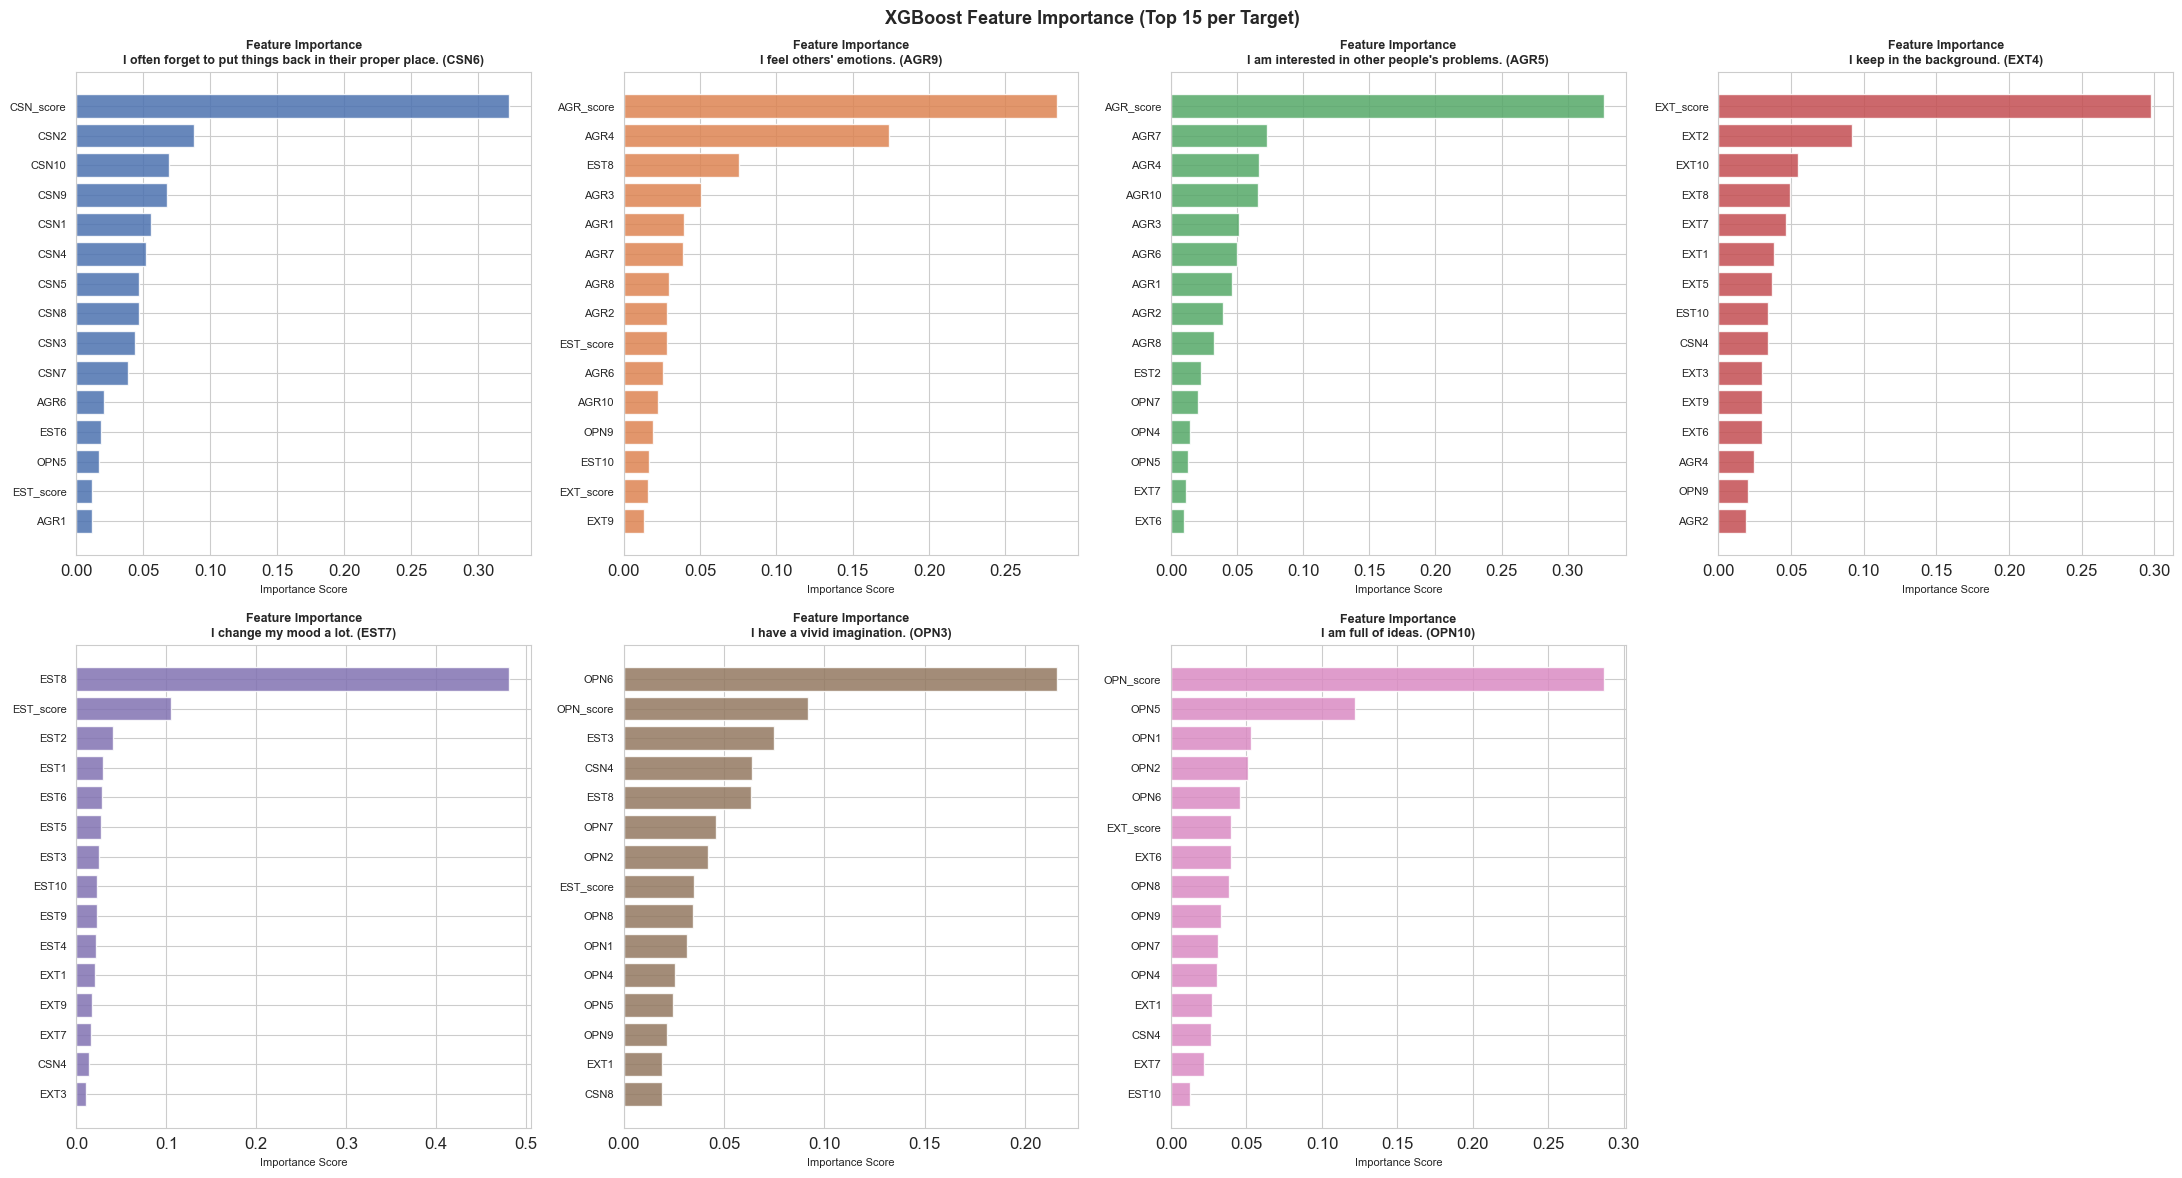

In [13]:
# Feature Importance (Top 15 per target)
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    importance = pd.Series(models[target].feature_importances_, index=FEATURE_COLS)
    top15 = importance.sort_values(ascending=False).head(15)

    ax.barh(top15.index[::-1], top15.values[::-1], color=colors[i], alpha=0.85)
    ax.set_title(f'Feature Importance\n{TARGET_LABELS[target]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('XGBoost Feature Importance (Top 15 per Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Save Models

บันทึกโมเดลด้วย XGBoost native format (`.ubj`) — เร็วกว่า joblib และ portable กว่า

In [14]:
import pickle

os.makedirs('xgb_models', exist_ok=True)

for target, model in models.items():
    path = f'xgb_models/xgb_{target}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

print('\nAll models saved successfully.')

Saved: xgb_models/xgb_CSN6.pkl
Saved: xgb_models/xgb_AGR9.pkl
Saved: xgb_models/xgb_AGR5.pkl
Saved: xgb_models/xgb_EXT4.pkl
Saved: xgb_models/xgb_EST7.pkl
Saved: xgb_models/xgb_OPN3.pkl
Saved: xgb_models/xgb_OPN10.pkl

All models saved successfully.


---
## 8. Summary

In [15]:
print('=' * 70)
print('              FINAL MODEL SUMMARY — XGBoost')
print('=' * 70)
print(f'  Total samples used : {len(X):,}')
print(f'  Train / Test split : 80% / 20%')
print(f'  Features           : {len(FEATURE_COLS)} (43 items + 5 trait scores)')
print(f'  Targets            : {len(TARGET_COLS)} behaviors')
print('-' * 70)
print(f'  {"Target":<32} {"Best Iter":>10} {"Train MAE":>12} {"Test MAE":>12}')
print('-' * 70)
for col in TARGET_COLS:
    r = results[col]
    print(f'  {TARGET_LABELS[col]:<32} {r["best_iter"]:>10} {r["MAE_train"]:>12.4f} {r["MAE_test"]:>12.4f}')
print('-' * 70)
avg_test  = np.mean([results[c]['MAE_test']  for c in TARGET_COLS])
avg_train = np.mean([results[c]['MAE_train'] for c in TARGET_COLS])
print(f'  {"AVERAGE":<32} {"":>10} {avg_train:>12.4f} {avg_test:>12.4f}')
print('=' * 70)
print(f'\n  Scale: 1–5  →  MAE < 0.5 ถือว่าอยู่ในเกณฑ์ดี')
print(f'  Average Test MAE ≈ {avg_test:.3f} (ผิดพลาดเฉลี่ย {avg_test:.2f} คะแนน)')

              FINAL MODEL SUMMARY — XGBoost
  Total samples used : 874,434
  Train / Test split : 80% / 20%
  Features           : 48 (43 items + 5 trait scores)
  Targets            : 7 behaviors
----------------------------------------------------------------------
  Target                            Best Iter    Train MAE     Test MAE
----------------------------------------------------------------------
  I often forget to put things back in their proper place. (CSN6)        499       0.4110       0.4165
  I feel others' emotions. (AGR9)         499       0.4276       0.4299
  I am interested in other people's problems. (AGR5)        499       0.4372       0.4392
  I keep in the background. (EXT4)        499       0.4149       0.4163
  I change my mood a lot. (EST7)          499       0.4041       0.4066
  I have a vivid imagination. (OPN3)        499       0.3781       0.3809
  I am full of ideas. (OPN10)             499       0.3650       0.3665
----------------------------------